In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
import os
import hubble_fit
from hubble_fit import *
from hubble_utils import *
from hubble_likelihood import *
from hubble_plotting import *
from hubble_model import *
from hubble_completeness_refactored import *

CPU Num Cores: 6


In [2]:
from completeness_mock_catalog import (
    COSMO,
    build_shen_lf,
    mock_m_per_zbin,
    save_mock_catalog,
)

In [3]:
# --------------------------------------------------
# 1. Load AGN sample
# --------------------------------------------------
h5_file = "results/data/nov10a_single_chisq_carma_mixscalar_nozband_highertaufastlim_removemix_fixband_lagblrband_chisq_spl_nofhost_bwb_lmc-6_N1w1000s200t14ch4.h5"
spectra_fit_csv = "results/data/jaxqsofit_mar15c.csv"

df_agn, df_agn_all = load_agn_data(
    h5_file,
    only_load=False,
    fhost_cut=10,
    spectra_fit_csv=[spectra_fit_csv],
    correct_sigma_uv_host=False,
    pickled=True,
    plot_path="plots/hubble/completeness_refresh",
)

# --------------------------------------------------
# 2. Generate Hopkins mock catalog
# --------------------------------------------------
phi_log10, m_grid, z_bins = build_shen_lf(None)

rng = np.random.default_rng(123)
_, nexp, _, nsel, z_all, m_all, m_2500_all, bin_index = mock_m_per_zbin(
    phi_log10,
    m_grid,
    z_bins,
    area_deg2=5.0,
    alpha_nu=-0.5,
    dalpha_nu=0.3,
    cosmo=COSMO,
    z_res=512,
    m_scatter=0.0,
    kcorr_zref=2.0,
    m_lim=28.0,
    rng=rng,
    return_z=True,
    return_global=True,
    verbose=True,
)

sim_file = "/Users/colinburke/research/qvc/data/mock_mag_z_hopkins.h5"
save_mock_catalog(sim_file, z_all, m_all, m_2500_all, m_limit=28.0)
print(f"Saved mock catalog: {sim_file}")
print(f"Generated {len(z_all)} mock sources before final save cut.")

# --------------------------------------------------
# 3. Build completeness map from that mock
# --------------------------------------------------
completeness2d, mag_centers, z_centers, dm, dz, sigma_mag = get_completeness_function_2d(
    df_agn,
    sim_file=sim_file,
    n_mag_bins=30,
    n_z_bins=40,
    smooth_counts=True,
    plot=True,
    plot_path="plots/hubble/completeness_refresh",
    fill_along_mag=False,
    fill_along_z=False,
)

print("Done.")
print("Completeness sim file:", sim_file)
print("mag grid:", mag_centers.shape, mag_centers.min(), mag_centers.max())
print("z grid:", z_centers.shape, z_centers.min(), z_centers.max())
print("sigma_mag used:", sigma_mag)

Number of quasars loaded: 13090
Entire Sample file length: 13193
Populating spectra fit data from: ['results/data/jaxqsofit_mar15c.csv']
Loading spectra fit CSV (1/1): results/data/jaxqsofit_mar15c.csv
Length of merged DataFrame (best=True): 13090
Cut on apparent_mag_2500 : 222 objects removed
['usrid', 'separation', 'probability', 'name', 'ra', 'dec', 'err_ellipse_r0', 'err_ellipse_r1', 'err_ellipse_ang', 'significance', 'likelihood_class', 'conf_flag', 'sat_src_flag', 'streak_src_flag', 'flux_aper_b', 'flux_aper_lolim_b', 'flux_aper_hilim_b', 'flux_aper_w', 'flux_aper_lolim_w', 'flux_aper_hilim_w', 'flux_aper_avg_b', 'flux_aper_avg_lolim_b', 'flux_aper_avg_hilim_b', 'flux_aper_avg_w', 'flux_aper_avg_lolim_w', 'flux_aper_avg_hilim_w']
Matched 294 out of 12868 objects to CSC3 catalog.
Populating LC info from: data/aug4_sample_chisqg10_ebv005sn3_lcdata.csv
Length of lc info merged DataFrame: 12868
object_id not in merged: []
Populating LC info from: data/aug4_sample_chisqg10_ebv005sn3.c

In [ ]:


r = hubble_fit.run_single(df_agn, df_agn_all, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model, completeness=True, use_full_cov=False, 
                    resume=False,
                    only_sna=False, speed=speed, skip_plots=False)

samples_sna, model_labels_sna, dm_interp_sna, logZ_sna, logZerr_sna, debiased_residuals_sna, age_sna, age_sna_err = r


NameError: name 'df_pantheon' is not defined

In [ ]:
df_agn.columns.tolist()

CPU Num Cores: 6


['object_id',
 'LOGL5100',
 'LOGL5100_ERR',
 'LOGLBOL',
 'LOGLBOL_ERR',
 'alpha_agn',
 'alpha_agn_acf',
 'alpha_agn_err',
 'alpha_agn_ess',
 'alpha_agn_per_chain_variance',
 'alpha_agn_rhat',
 'alpha_agn_stuck_any',
 'alpha_agn_stuck_chains',
 'alpha_host',
 'alpha_host_acf',
 'alpha_host_err',
 'alpha_host_ess',
 'alpha_host_per_chain_variance',
 'alpha_host_rhat',
 'alpha_host_stuck_any',
 'alpha_host_stuck_chains',
 'bands',
 'bwb_alpha',
 'bwb_alpha_err',
 'cadence',
 'cadence_err',
 'cov_log_sigma_UV_log_tau_UV_RF',
 'dec',
 'dropped_bands',
 'eta_A1',
 'eta_A1_acf',
 'eta_A1_err',
 'eta_A1_ess',
 'eta_A1_per_chain_variance',
 'eta_A1_rhat',
 'eta_A1_stuck_any',
 'eta_A1_stuck_chains',
 'eta_A2',
 'eta_A2_acf',
 'eta_A2_err',
 'eta_A2_ess',
 'eta_A2_per_chain_variance',
 'eta_A2_rhat',
 'eta_A2_stuck_any',
 'eta_A2_stuck_chains',
 'eta_break',
 'eta_break_err',
 'eta_tau1',
 'eta_tau1_acf',
 'eta_tau1_err',
 'eta_tau1_ess',
 'eta_tau1_per_chain_variance',
 'eta_tau1_rhat',
 'eta_t

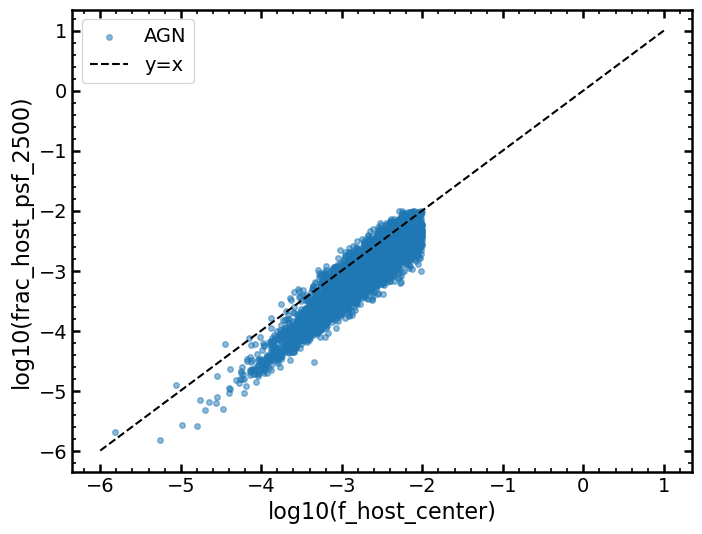

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(np.log10(df_agn['f_host_center']), np.log10(df_agn['frac_host_psf_2500']), label='AGN', alpha=0.5)
ax.set_xlabel('log10(f_host_center)')
ax.set_ylabel('log10(frac_host_psf_2500)')
ax.plot([-6, 1], [-6, 1], 'k--', label='y=x')
ax.legend()
plt.show()

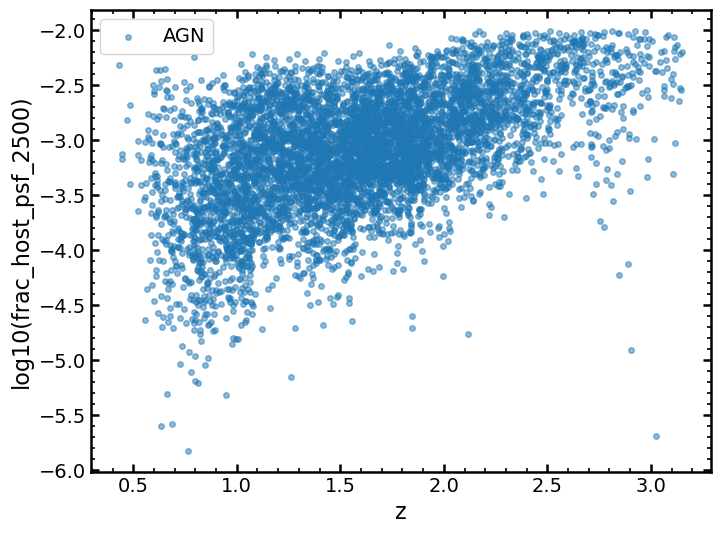

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df_agn['z'], np.log10(df_agn['frac_host_psf_2500']), label='AGN', alpha=0.5)
ax.set_xlabel('z')
ax.set_ylabel('log10(frac_host_psf_2500)')
#ax.set_ylim(0, .8)
ax.legend()
plt.show()

In [ ]:
residuals, residuals_err, mu_pred_median, mu_pred_std, mu_pred_std_with_scatter = plot_hubble(flat_samples, df_agn, df_pantheon, cosmo_model, z_pivot_agn,
            plot_path=f"plots/hubble/{prefix}", show_binned_agn=True, show_residuals=True,
            debias=True, dm_interp=dm_interp, show=True, completeness=True, verbose=False,
            cosmo_model_samples={})

NameError: name 'flat_samples' is not defined